## Pembuatan Model untuk Skripsi

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

require_score = 400
folder_file = "stringdb_web_tsv_short"
nama_file = f"stringdb_result_{require_score}.tsv"

dataset = f"{folder_file}/{nama_file}"

df = pd.read_csv(dataset, sep='\t')

subset = df[["preferredName_A", "preferredName_B", "score"]]

nodes = pd.concat([subset["preferredName_A"], subset["preferredName_B"]]).unique()
node_to_id = {node: i for i, node in enumerate(nodes)} 

edges = np.array([
	[node_to_id[a], node_to_id[b]]
		for a, b in zip(df["preferredName_A"], df["preferredName_B"])
])

num_nodes = len(nodes)

row = edges[:, 0]
col = edges[:, 1]
data = df["score"].values 

row2 = edges[:,1]
col2 = edges[:,0]
data2 = df["score"].values

row = np.concatenate([row, row2])
col = np.concatenate([col, col2])
data = np.concatenate([data, data2])

A = sp.csr_matrix((data, (row, col)), shape=(num_nodes, num_nodes))

print("✅ Adjancency matrix (A) didapatkan")

✅ Adjancency matrix (A) didapatkan


In [2]:
N = A.shape[0]

# 1. Density
density_baseline = A.nnz / (N**2 - N)

# 2. Clustering Coefficient
num_triangles = (A @ A @ A).diagonal().sum() / 6
num_possible_triangles = (N - 2) * (N - 1) * N / 6
clust_coef_baseline = num_triangles / num_possible_triangles

print(f'Data Awal (Graf Asli):\n'
	f'Density    = {density_baseline:.4f}\n'
	f'Clustering Coefficient = {clust_coef_baseline:.4f}')

print("\n✅ Analisis Topologi Selesai dilakukan")


Data Awal (Graf Asli):
Density    = 0.0691
Clustering Coefficient = 0.0011

✅ Analisis Topologi Selesai dilakukan


In [3]:
from sklearn.preprocessing import normalize 
import nocd

data_norm = normalize(A)
data_norm = nocd.utils.to_sparse_tensor(data_norm)

print("✅ Data Normalisasi sparse tensor sesuai PyTorch !!! ")

✅ Data Normalisasi sparse tensor sesuai PyTorch !!! 


d:\Kuliah\program-skripsi\temp\overlapping-community-detection\nocd\utils.py:41: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:656.)
  sparse_tensor = torch.sparse.FloatTensor(indices, values, shape)


1. Estimasi Heuristik (Rule of Thumbs) :
17.10263137648707

2. Optimasi Modularitas Multi-Resolution :
Resolution 1.0 -> Ditemukan K = 5 (Avg Size: 117.0 nodes) ~ (modularity : 0.35)
Resolution 1.5 -> Ditemukan K = 11 (Avg Size: 53.2 nodes) ~ (modularity : 0.27)
Resolution 2.0 -> Ditemukan K = 20 (Avg Size: 29.2 nodes) ~ (modularity : 0.21)
Resolution 2.5 -> Ditemukan K = 32 (Avg Size: 18.3 nodes) ~ (modularity : 0.18)
Resolution 3.0 -> Ditemukan K = 42 (Avg Size: 13.9 nodes) ~ (modularity : 0.15)
Resolution 3.5 -> Ditemukan K = 51 (Avg Size: 11.5 nodes) ~ (modularity : 0.13)
Resolution 4.0 -> Ditemukan K = 59 (Avg Size: 9.9 nodes) ~ (modularity : 0.11)
Resolution 4.5 -> Ditemukan K = 69 (Avg Size: 8.5 nodes) ~ (modularity : 0.09)
Resolution 5.0 -> Ditemukan K = 75 (Avg Size: 7.8 nodes) ~ (modularity : 0.08)

3.	Validasi Elbow Method  :


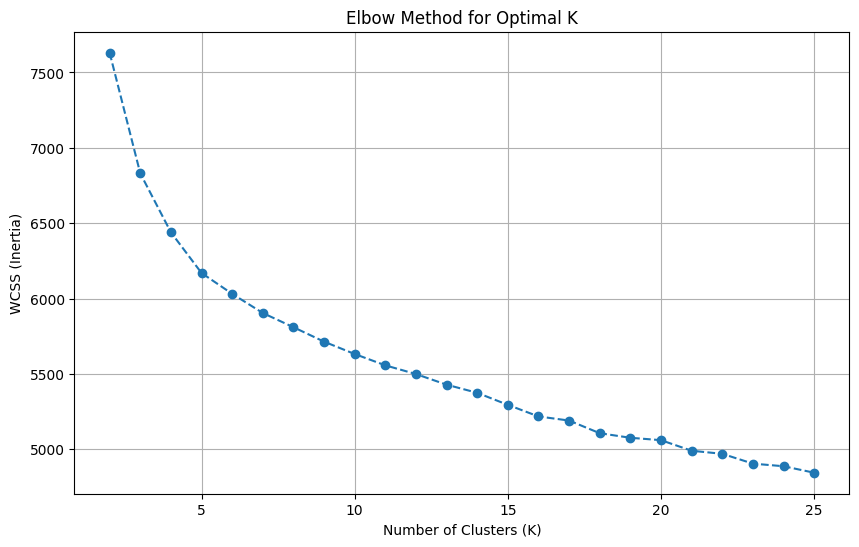

✅ Nilai K dapat disimpulkan 

Nilai K yang dipilih adalah = 16


In [ ]:
# 1. Rule of Thumbs
from math import sqrt

# Perhitungan
jml_nodes = len(nodes)
hasil = sqrt( jml_nodes / 2)
print("1. Estimasi Heuristik (Rule of Thumbs) :")
print(hasil)  

# 2. Optimasi Modularitas Multi-Resolution
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def find_optimal_k(A, resolutions=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]):
    G_nx = nx.from_scipy_sparse_array(A)
    
    results = []
    
    for res in resolutions:
        comms = nx.community.louvain_communities(G_nx, weight='weight', resolution=res)
        
        k_found = len(comms)
        modularity = nx.community.modularity(G_nx, comms, weight='weight', resolution=res)
        avg_size = np.mean([len(c) for c in comms])
        
        print(f"Resolution {res:.1f} -> Ditemukan K = {k_found} (Avg Size: {avg_size:.1f} nodes) ~ (modularity : {modularity:.2f})")
        results.append((res, k_found))
        
    return results

print("\n2. Optimasi Modularitas Multi-Resolution :")
find_optimal_k(A)

# 3. Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
%matplotlib inline

wcss = []
k_range = range(2, 26)  

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(A) 
    wcss.append(kmeans.inertia_) 

print("\n3.	Validasi Elbow Method  :")
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)') 
plt.ylabel('WCSS (Inertia)')         
plt.grid(True)
plt.show()

print("✅ Nilai K dapat disimpulkan ")

print("\nNilai K yang dipilih adalah = 16")

In [ ]:
"""
Set Hypermarater
"""
hidden_sizes = [128]    # ukuran tersembunyi dari GNN
weight_decay = 1e-2     # kekuatan regularisasi L2 pada bobot GNN (0,01)
dropout = 0.5           # apakah akan menggunakan dropout
batch_norm = True       # apakah akan menggunakan batch_norm
lr = 1e-3               # kecepatan pembelajaran (0,001)
max_epochs = 3000       # jumlah epoch untuk dilatih
display_step = 25       # seberapa sering menghitung validation_loss
balance_loss = True     # apakah akan menggunakan balance_loss
stochastic_loss = True  # apakah akan menggunakan stochastic atau full-batch training
batch_size = 20000      # ukuran batch (hanya untuk pelatihan stokastik)

print("✅ Hypermarater ditetapkan")

✅ Hypermarater ditetapkan


In [ ]:
"""
Membangun Model GNN nya
"""
import torch 

K = 16
N = A.shape[0] 

sampler = nocd.sampler.get_edge_sampler(A, batch_size, batch_size, num_workers=4)
gnn = nocd.nn.GCN(data_norm.shape[1], hidden_sizes, K, batch_norm=batch_norm, dropout=dropout)
adj_norm = gnn.normalize_adj(A) 
decoder = nocd.nn.BerpoDecoder(N, A.nnz, balance_loss=balance_loss)
opt = torch.optim.Adam(gnn.parameters(), lr=lr)

print("✅ Persiapan Model GNN selesai ")

✅ Persiapan Model GNN selesai 


In [ ]:
"""
Melakukan Training dan Validasi Model GNN
"""
import torch.nn.functional as F

val_loss = np.inf
train_loss_current = 0.0
validation_fn = lambda: val_loss
early_stopping = nocd.train.NoImprovementStopping(validation_fn, patience=10)
model_saver = nocd.train.ModelSaver(gnn)

for epoch, batch in enumerate(sampler):
	if epoch > max_epochs:
		break
	if epoch % 25 == 0:
		with torch.no_grad():
			gnn.eval()
			Z = F.relu(gnn(data_norm, adj_norm))
			val_loss = decoder.loss_full(Z, A)

			print(f"Epoch {epoch}: loss.full: {val_loss:.4f}")

			early_stopping.next_step()
			if early_stopping.should_save():
				model_saver.save()
			if early_stopping.should_stop():
				print(f"Breaking due to early stopping at epoch {epoch}")
				break
	
	gnn.train()
	opt.zero_grad()
	Z = F.relu(gnn(data_norm, adj_norm))
	ones_idx, zeros_idx = batch
	if stochastic_loss:
		loss = decoder.loss_batch(Z, ones_idx, zeros_idx)
	else:
		loss = decoder.loss_full(Z, A)
		
	loss = decoder.loss_full(Z, A)
	loss += nocd.utils.l2_reg_loss(gnn, scale=weight_decay)

	loss.backward()
	opt.step()

print("✅ Model GNN selesai di Train")

Epoch 0: loss.full: 0.7140
Epoch 25: loss.full: 0.3825
Epoch 50: loss.full: 0.3397
Epoch 75: loss.full: 0.3291
Epoch 100: loss.full: 0.3088
Epoch 125: loss.full: 0.3022
Epoch 150: loss.full: 0.2974
Epoch 175: loss.full: 0.2935
Epoch 200: loss.full: 0.2928
Epoch 225: loss.full: 0.2877
Epoch 250: loss.full: 0.2894
Epoch 275: loss.full: 0.2882
Epoch 300: loss.full: 0.2835
Epoch 325: loss.full: 0.2836
Epoch 350: loss.full: 0.2929
Epoch 375: loss.full: 0.2851
Epoch 400: loss.full: 0.2810
Epoch 425: loss.full: 0.2813
Epoch 450: loss.full: 0.2817
Epoch 475: loss.full: 0.2831
Epoch 500: loss.full: 0.2811
Epoch 525: loss.full: 0.2826
Epoch 550: loss.full: 0.2834
Epoch 575: loss.full: 0.2805
Epoch 600: loss.full: 0.2803
Epoch 625: loss.full: 0.2827
Epoch 650: loss.full: 0.2807
Epoch 675: loss.full: 0.2794
Epoch 700: loss.full: 0.2809
Epoch 725: loss.full: 0.2803
Epoch 750: loss.full: 0.2788
Epoch 775: loss.full: 0.2815
Epoch 800: loss.full: 0.2809
Epoch 825: loss.full: 0.2798
Epoch 850: loss.ful

In [ ]:
# """
# Menyimpan Model yang telah di train
# """
# # Menyiapkan Config yang digunakan
# config_param = {
# 	'input_dim': data_norm.shape[1],
# 	'hidden_dims': hidden_sizes,
# 	'output_dim': K,
# 	'batch_norm': batch_norm,
# 	'dropout': dropout,
# }

# # Menyiapkan checkpoint dari model yang udah di train
# checkpoint = {
# 	'hyperparameters': config_param,
# 	'model_state': gnn.state_dict() # ini bobot/otaknya
# }

# # Menyiapkan path folder dan nama file
# path_folder = "result_models"
# nama_model = f"model_K{K}_dataset{require_score}_short.pth"
# final_file = f"{path_folder}/{nama_model}"

# # Menimpan Model
# torch.save(checkpoint, final_file)

# print(f"✅ Model GNN selesai disimpan di '{final_file}' ")

✅ Model GNN selesai disimpan di 'result_models/model_K16_dataset400_short.pth' 


In [ ]:
# Tahap 1. Load Model
import torch
import nocd

# Menyiapkan path folder dan nama file
path_folder = "result_models"
nama_model = "model_K16_dataset400_short_demo.pth"
model_path = f"{path_folder}/{nama_model}"

# Load Model yang udah disimpan
load_model = torch.load(model_path)

# Ekstrak hyperparameter menjadi config
config = load_model['hyperparameters'] 

# Buat model baru
model_baru = nocd.nn.GCN(
  input_dim = config['input_dim'], 
  hidden_dims = config['hidden_dims'], 
  output_dim = config['output_dim'], 
  batch_norm = config['batch_norm'],
  dropout = config['dropout']
  )

# Load Checkpoint sebelumnya
model_baru.load_state_dict(load_model['model_state'])

# Model evaluasi
model_baru.eval()

print("✅ Modle berhasil di load 🌟")
print("Sampai sini udah bisa seperti biasanya")

model_baru.eval()
Z_numpy = Z.cpu().detach().numpy()

thresh = 0.5
Z_pred = Z_numpy > thresh



✅ Modle berhasil di load 🌟
Sampai sini udah bisa seperti biasanya


In [ ]:
"""
Proses Thresholding 
"""
gnn.eval()
Z_numpy = Z.cpu().detach().numpy()

thresh = 0.5
Z_pred = Z_numpy > thresh

print(f"✅ Thresholding selesai dilakukan 🌟")

✅ Thresholding selesai dilakukan 🌟


In [ ]:
"""
Proses Jaring Pengaman (Safety Net)
= Agar tidak ada node yang "jomblo" (tanpa komunitas)
"""
# Deteksi Node "Jomblo" (Tanpa Komunitas)
num_orphans = Z_pred.sum(axis=1) == 0
print(f"Jumlah node tanpa komunitas awal : {num_orphans.sum()}")

# Untuk node yang "jomblo", ambil indeks dengan nilai Z tertinggi (argmax)
orphan_rows = Z_numpy[num_orphans]
best_community_indices = orphan_rows.argmax(axis=1)

# Update Z_pred: set menjadi true pada indeks komunitas terbaik tersebut
node_indices = np.where(num_orphans)[0]

# Set True secara spesifik
Z_pred[node_indices, best_community_indices] = True
print(f"Jumlah node tanpa komunitas setelah fix: {(Z_pred.sum(axis=1) == 0).sum()} \n")

print(f"✅ Jaring Pengaman (Safety Net) berhasil dilakukan ")


Jumlah node tanpa komunitas awal : 84
Jumlah node tanpa komunitas setelah fix: 0 

✅ Jaring Pengaman (Safety Net) berhasil dilakukan 


In [ ]:
"""
Menampilkan Komunitas dan isinya apa aja
"""
# Buat List Komunitas
communities_list = nocd.utils.coms_matrix_to_list(Z_pred)

# Buat Dictionary node to id, untuk menampilkan komunitas nanti
node_names = {node: i for i, node in node_to_id.items()}

# Fungsi untuk memetakan indeks ke nama (PERBAIKAN di sini!)
def map_indices_to_names(index_list, node_names):
	# MENGGUNAKAN LIST COMPREHENSION: mengambil nama untuk setiap indeks dalam list
	return [node_names[index] for index in index_list]

count = 0
for i, community_indices in enumerate(communities_list):
	# Memeriksa apakah komunitas tersebut memiliki anggota
	if len(community_indices) > 0:        
		# community_indices adalah list indeks node
		community_names = map_indices_to_names(community_indices, node_names)
		
		print(f"Komunitas {i+1} (Jumlah Node: {len(community_names)}):")
		
		# Menampilkan node, dibatasi hingga 10 node pertama per komunitas untuk output yang ringkas
		if len(community_names) > 10:
			# Tidak perlu .tolist() lagi karena sudah menjadi list Python
			first_ten_names = community_names[:10] 
			print(f"  {first_ten_names} ... [Total {len(community_names)} node]")
		else:
			print(f"  {community_names}")
		count += 1

print(f"\n\n✅ Data berhasil ditampilkan ")

Komunitas 1 (Jumlah Node: 131):
  ['ABCB1', 'ACTB', 'AGO2', 'ALB', 'ALK', 'AR', 'ARID1A', 'ARID1B', 'ARID2', 'ARNT'] ... [Total 131 node]
Komunitas 2 (Jumlah Node: 109):
  ['ABL1', 'ABL2', 'ACTB', 'ALB', 'ALK', 'ARHGAP35', 'ARHGEF10L', 'ARHGEF12', 'ARHGEF28', 'AXL'] ... [Total 109 node]
Komunitas 3 (Jumlah Node: 102):
  ['ACTB', 'AGO2', 'ALB', 'APH1A', 'AR', 'ARID1A', 'ARNT', 'BCL2', 'CBFA2T3', 'CDH1'] ... [Total 102 node]
Komunitas 4 (Jumlah Node: 78):
  ['ABRAXAS1', 'ATM', 'ATMIN', 'ATR', 'ATRX', 'BLM', 'BRCA1', 'BRCA2', 'BRIP1', 'BUB1B'] ... [Total 78 node]
Komunitas 5 (Jumlah Node: 77):
  ['ABL1', 'ABL2', 'AFF1', 'ARID1A', 'ASXL1', 'BCL2', 'BCORL1', 'BCR', 'BRD4', 'CALR'] ... [Total 77 node]
Komunitas 6 (Jumlah Node: 34):
  ['ABCC3', 'AIP', 'ALK', 'ATIC', 'BIRC6', 'CLIP1', 'CLTC', 'CNTRL', 'DCTN1', 'EML4'] ... [Total 34 node]
Komunitas 7 (Jumlah Node: 37):
  ['ACSL3', 'ASPSCR1', 'ATP1A1', 'ATP2B3', 'ATP6AP1', 'ATP6V1B2', 'CACNA1D', 'CAMTA1', 'CCT6B', 'CREB3L2'] ... [Total 37 node]


In [12]:
print(f'Data Analisis Topologi Awal (Graf Asli):\n'
	f'- density    = {density_baseline:.4f}\n'
	f'- clust_coef = {clust_coef_baseline:.4f}')

metrics = nocd.metrics.evaluate_unsupervised(Z_pred, A)
print(f"\nHasil Prediksi Komunitas:\n"
	f"- coverage    = {metrics['coverage']:.4f}\n"
	f"- conductance = {metrics['conductance']:.4f}\n"
	f"- density     = {metrics['density']:.4f}\n"
	f"- clust_coef  = {metrics['clustering_coef']:.4f}")


# Perbandingan Density
if density_baseline < metrics['density'] :
	print("Densitas : Naik ~ (Makin Rapat) ")
elif density_baseline > metrics['density'] :
	print("Densitas : Turun ~ (Makin Rengang) ")

# Perbandingan Clustering Coefficient
if clust_coef_baseline < metrics['clustering_coef'] :
	print("Clustering Coefficient : Naik ")
elif clust_coef_baseline > metrics['clustering_coef'] :
	print("Clustering Coefficient : Turun")


Data Analisis Topologi Awal (Graf Asli):
- density    = 0.0691
- clust_coef = 0.0011

Hasil Prediksi Komunitas:
- coverage    = 0.8286
- conductance = 0.5643
- density     = 0.3452
- clust_coef  = 0.0331
Densitas : Naik ~ (Makin Rapat) 
Clustering Coefficient : Naik 


In [13]:
"""
Evaluasi Biologis dengan Enrichment Analysis
= Dengan Libary GProfiler untuk Enrichment Analysisnya
"""
# Import library yang diperlukan
from gprofiler import GProfiler

# Init tool
gp = GProfiler(return_dataframe=True)

# Defini list yang akan dilakukan Enrichment Analysis
gene_list = ["ABL1", "CXCR4", "ABCB1", "TP53", "ARID1A", "ANKRD11"] # Ganti isinya berdasarkan hasil komunitas

# Jalankan Enrichment Analysis
results = gp.profile(
	organism = 'hsapiens',    # Organisme (hsapiens = Human, mmusculus = Mouse)
	query = gene_list,        # List gen yang mau dianalisis
	sources = ['GO:BP', 'GO:MF', 'GO:CC', 'KEGG'], # Sumber data (Biological Process, KEGG, Reactome)
	user_threshold = 0.05,    # Ambang batas signifikansi (p-value)
	no_evidences = False      # Set False agar kita bisa lihat gen apa saja yang overlap
)

# Tampilkan Hasilnya
results.head()

# (Opsional) Simpan hasil nya
# path_folder = "result_enrichment_analysis"
# nama_file = "result_EA.csv"
# final_file = f"{path_folder}/{nama_file}"
# results.to_csv(final_file, index=False)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:BP,GO:0009410,response to xenobiotic stimulus,0.002429,True,"""Any process that results in a change in state...",439,6,4,21026,0.666667,0.009112,query_1,[GO:0042221],"[ABL1, CXCR4, ABCB1, TP53]","[[IEA], [IEA], [TAS], [IEP, IEA]]"
1,GO:MF,GO:0031625,ubiquitin protein ligase binding,0.011130,True,"""Binding to a ubiquitin protein ligase enzyme,...",306,6,3,20246,0.500000,0.009804,query_1,[GO:0044389],"[CXCR4, ABCB1, TP53]","[[IPI], [IPI], [EXP, IPI, IEA]]"
2,GO:MF,GO:0044389,ubiquitin-like protein ligase binding,0.013192,True,"""Binding to a ubiquitin-like protein ligase, s...",324,6,3,20246,0.500000,0.009259,query_1,[GO:0019899],"[CXCR4, ABCB1, TP53]","[[IPI], [IPI], [EXP, IPI, IEA]]"
3,GO:BP,GO:0071466,cellular response to xenobiotic stimulus,0.013954,True,"""Any process that results in a change in state...",196,6,3,21026,0.500000,0.015306,query_1,"[GO:0009410, GO:0070887]","[CXCR4, ABCB1, TP53]","[[IEA], [TAS], [IEP]]"
4,KEGG,KEGG:05206,MicroRNAs in cancer,0.022424,True,MicroRNAs in cancer,310,5,3,8484,0.600000,0.009677,query_1,[KEGG:00000],"[ABL1, ABCB1, TP53]","[[KEGG], [KEGG], [KEGG]]"


In [14]:
"""
Perhitungan -log10(p-value) dan menampilkan hasilnya
= Semakin tinggi -log10p nya, semakin kuat fungsi terkait penyakit 
"""
# Import library yang diperlukan
import numpy as np

# Hitung -log10(p-value) menggunakan numpy agar lebih cepat dan stabil
# Kita gunakan -np.log10 pada kolom 'p_value'
results['-log10p'] = -np.log10(results['p_value'])

# Memilih dan mengurutkan kolom yang ingin ditampilkan
# Anda bisa menyesuaikan list di bawah ini dengan nama kolom yang Anda inginkan
display_columns = ['source', 'native', 'name', 'p_value', '-log10p', 'significant']

# 3. Urutkan berdasarkan -log10p tertinggi (p-value terkecil)
results_sorted = results[display_columns].sort_values(by='-log10p', ascending=False)

# 4. Tampilkan dataframe
results_sorted.head(10)

,source,native,name,p_value,-log10p,significant
0,GO:BP,GO:0009410,response to xenobiotic stimulus,0.002429,2.614617,True
1,GO:MF,GO:0031625,ubiquitin protein ligase binding,0.011130,1.953513,True
2,GO:MF,GO:0044389,ubiquitin-like protein ligase binding,0.013192,1.879682,True
3,GO:BP,GO:0071466,cellular response to xenobiotic stimulus,0.013954,1.855302,True
4,KEGG,KEGG:05206,MicroRNAs in cancer,0.022424,1.649294,True
5,GO:BP,GO:0060322,head development,0.026988,1.568832,True
6,GO:BP,GO:0060284,regulation of cell development,0.032819,1.483879,True
7,GO:BP,GO:0060218,hematopoietic stem cell differentiation,0.038008,1.420123,True
8,KEGG,KEGG:05220,Chronic myeloid leukemia,0.038150,1.418501,True
9,GO:BP,GO:0000278,mitotic cell cycle,0.040241,1.395333,True


In [ ]:
import pandas as pd
from gprofiler import GProfiler
import numpy as np

gp = GProfiler(return_dataframe=True)

id_to_node = {idx: name for name, idx in node_to_id.items()}

all_enrichment_results = []

for i, community_indices in enumerate(communities_list):
    if len(community_indices) > 0:
        gene_list = [id_to_node[index] for index in community_indices]
        
        community_name = f"Komunitas {i+1}"
        
        res = gp.profile(
                organism='hsapiens',
                query=gene_list,
                sources=['GO:BP', 'GO:MF', 'GO:CC', 'KEGG']
                user_threshold=0.05,
                no_evidences=False
        )
            
        res['community_id'] = community_name
        res['protein_members'] = ", ".join(gene_list)
                            
        all_enrichment_results.append(res)

if all_enrichment_results:
    final_df = pd.concat(all_enrichment_results, ignore_index=True)
    
    cols = ['community_id', 'source', 'native', 'name', 'p_value', 'description', 'intersections', 'protein_members']

    available_cols = [c for c in cols if c in final_df.columns]
    final_df = final_df[available_cols]
    
final_df.head()

final_df.to_excel("result_enrichment_analysis.xlsx", index=False)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22404\1761716744.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(all_enrichment_results, ignore_index=True)


In [ ]:
from gprofiler import GProfiler
import ast
import math

# 1. Inisialisasi tool
gp = GProfiler(return_dataframe=True)

id_to_node = {idx: name for name, idx in node_to_id.items()}
all_enrichment_results = []

# 2. Definisikan list gen Anda (contoh: gen terkait siklus sel/kanker)
gene_list = [id_to_node[index] for index in community_indices]

# 3. Jalankan enrichment analysis (g:GOSt)
results = gp.profile(
	organism='hsapiens',    # Organisme (hsapiens = Human, mmusculus = Mouse)
	query=gene_list,        # List gen yang mau dianalisis
	sources=['GO:BP', 'GO:MF', 'GO:CC', 'KEGG'], # Sumber data (Biological Process, KEGG, Reactome)
	user_threshold=0.05,    # Ambang batas signifikansi (p-value)
	no_evidences=False      # Set False agar kita bisa lihat gen apa saja yang overlap
)

# 5. Persiapkan struktur dictionary penampung
data_enrichment = {
	"data_bp": [],
	"data_mf": [],
	"data_cc": [],
	"data_kp": []
}

# 6. Iterasi setiap baris pada DataFrame 'results'
for index, row in results.iterrows():
	source = row['source']
	
	# Tentukan kunci kategori berdasarkan source
	category_key = None
	if source == 'GO:BP':
		category_key = 'data_bp'
	elif source == 'GO:MF':
		category_key = 'data_mf'
	elif source == 'GO:CC':
		category_key = 'data_cc'
	elif source == 'KEGG':
		category_key = 'data_kp'
	
	# Jika kategori sesuai dengan yang diinginkan, proses datanya
	if category_key:
		# Cek jika data sudah mencapai 20, jangan tambah lagi untuk kategori ini
		if len(data_enrichment[category_key]) >= 20:
			continue

		# Hitung -log10 dari p-value
		p_val = row['p_value']
		log10p = -math.log10(p_val) if p_val > 0 else 0
		
		# Ambil list gen (pastikan formatnya list)
		# GProfiler biasanya mengembalikan list, tapi jika dari CSV mungkin perlu diparsing
		gene_list_data = row['intersections']
		if isinstance(gene_list_data, str):
			# Jika terbaca sebagai string "['A', 'B']", kita bersihkan
			gene_list_data = ast.literal_eval(gene_list_data)

		# Buat dictionary item sesuai format yang diminta
		item = {
			"term_id": row['native'],       # ID Term (contoh: GO:00009748)
			"term_name": row['name'],       # Nama Term
			"log10p": f"{log10p:.2f}",      # Format string 2 desimal
			"p_value": f"{p_val:.2e}",      # Format scientific notation
			"gene_count": str(row['intersection_size']), # Jumlah gen yang overlap
			"gene_list": gene_list_data     # List nama gen
		}
		
		# Masukkan ke kategori yang sesuai
		data_enrichment[category_key].append(item)


### TAMBAHAN AJA BUKAN TERMASUK PROGRAM ASLI
Membantu dalam penulisan nantinya

In [16]:
import pandas as pd

# 1. Inisialisasi list untuk menampung data
data_komunitas = []

# Pastikan node_names adalah mapping dari {ID: Nama}
# Jika node_to_id adalah {Nama: ID}, maka kita balik:
id_to_node = {idx: name for name, idx in node_to_id.items()}

for i, community_indices in enumerate(communities_list):
    if len(community_indices) > 0:
        # Mengambil nama anggota
        community_names = [id_to_node[index] for index in community_indices]
        
        # 2. Masukkan data ke dalam list dalam bentuk dictionary
        data_komunitas.append({
            "Komunitas": f"Komunitas {i+1}",
            "Jumlah Protein": len(community_names),
            "Anggota Komunitas": ", ".join(map(str, community_names)) # Digabung jadi satu string agar rapi di Excel
        })

# 3. Ubah list menjadi DataFrame
df_komunitas = pd.DataFrame(data_komunitas)

# 4. Export ke Excel
nama_file = "Hasil_Komunitas_Protein.xlsx"
df_komunitas.to_excel(nama_file, index=False)

print(f"✅ Data berhasil disimpan ke dalam file: {nama_file}")
print(df_komunitas.head()) # Menampilkan 5 baris pertama di console

✅ Data berhasil disimpan ke dalam file: Hasil_Komunitas_Protein.xlsx
     Komunitas  Jumlah Protein  \
0  Komunitas 1             131   
1  Komunitas 2             109   
2  Komunitas 3             102   
3  Komunitas 4              78   
4  Komunitas 5              77   

                                   Anggota Komunitas  
0  ABCB1, ACTB, AGO2, ALB, ALK, AR, ARID1A, ARID1...  
1  ABL1, ABL2, ACTB, ALB, ALK, ARHGAP35, ARHGEF10...  
2  ACTB, AGO2, ALB, APH1A, AR, ARID1A, ARNT, BCL2...  
3  ABRAXAS1, ATM, ATMIN, ATR, ATRX, BLM, BRCA1, B...  
4  ABL1, ABL2, AFF1, ARID1A, ASXL1, BCL2, BCORL1,...  


In [18]:
import pandas as pd
from gprofiler import GProfiler
import numpy as np

# 1. Inisialisasi gProfiler
gp = GProfiler(return_dataframe=True)

# 2. Persiapkan mapping ID ke Nama Protein (jika belum ada)
# Di notebook Anda, node_to_id adalah {nama: id}, kita balik jadi {id: nama}
id_to_node = {idx: name for name, idx in node_to_id.items()}

# 3. List untuk menampung semua hasil enrichment
all_enrichment_results = []

print("⏳ Memulai Enrichment Analysis untuk setiap komunitas...")

for i, community_indices in enumerate(communities_list):
    if len(community_indices) > 0:
        # Ambil nama protein untuk komunitas ini
        gene_list = [id_to_node[index] for index in community_indices]
        
        # Nama komunitas (misal: Komunitas 1)
        community_name = f"Komunitas {i+1}"
        
        try:
            # Jalankan Enrichment Analysis
            res = gp.profile(
                organism='hsapiens',
                query=gene_list,
                sources=['GO:BP', 'GO:MF', 'KEGG', 'REAC'],
                user_threshold=0.05,
                no_evidences=False
            )
            
            if res is not None and not res.empty:
                # Tambahkan kolom identitas komunitas
                res['community_id'] = community_name
                res['protein_members'] = ", ".join(gene_list)
                
                # Simpan ke list besar
                all_enrichment_results.append(res)
                print(f"✅ {community_name}: Ditemukan {len(res)} istilah signifikan.")
            else:
                print(f"⚠️ {community_name}: Tidak ada istilah yang signifikan.")
                
        except Exception as e:
            print(f"❌ Error pada {community_name}: {e}")

# 4. Gabungkan semua hasil menjadi satu DataFrame
if all_enrichment_results:
    final_df = pd.concat(all_enrichment_results, ignore_index=True)
    
    # Atur urutan kolom agar lebih mudah dibaca (opsional)
    cols = ['community_id', 'source', 'native', 'name', 'p_value', 'description', 'intersections', 'protein_members']
    # Hanya ambil kolom yang tersedia
    available_cols = [c for c in cols if c in final_df.columns]
    final_df = final_df[available_cols]

    # 5. Simpan ke Excel
    file_output = "Enrichment_Analysis_Lengkap.xlsx"
    final_df.to_excel(file_output, index=False)
    
    print(f"\n✨ SELESAI! Semua hasil telah disimpan di: {file_output}")
else:
    print("\n❌ Tidak ada hasil enrichment yang ditemukan dari semua komunitas.")

⏳ Memulai Enrichment Analysis untuk setiap komunitas...
✅ Komunitas 1: Ditemukan 1442 istilah signifikan.
✅ Komunitas 2: Ditemukan 1323 istilah signifikan.
✅ Komunitas 3: Ditemukan 1073 istilah signifikan.
✅ Komunitas 4: Ditemukan 532 istilah signifikan.
✅ Komunitas 5: Ditemukan 597 istilah signifikan.
✅ Komunitas 6: Ditemukan 79 istilah signifikan.
✅ Komunitas 7: Ditemukan 159 istilah signifikan.
✅ Komunitas 8: Ditemukan 688 istilah signifikan.
✅ Komunitas 9: Ditemukan 167 istilah signifikan.
✅ Komunitas 10: Ditemukan 850 istilah signifikan.
✅ Komunitas 11: Ditemukan 948 istilah signifikan.
❌ Error pada Komunitas 12: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))
✅ Komunitas 13: Ditemukan 22 istilah signifikan.
⚠️ Komunitas 14: Tidak ada istilah yang signifikan.
✅ Komunitas 15: Ditemukan 42 istilah signifikan.
✅ Komunitas 16: Ditemukan 505 istilah signifikan.


PermissionError: [Errno 13] Permission denied: 'Enrichment_Analysis_Lengkap.xlsx'

In [ ]:
from gprofiler import GProfiler
import numpy as np

gp = GProfiler(return_dataframe=True)

gene_list = ["ABL1", "CXCR4", "ABCB1", "TP53", "ARID1A", "ANKRD11"] 

results = gp.profile(
    organism = 'hsapiens',    
    query = gene_list,        
    sources = ['GO:BP', 'GO:MF', 'GO:CC', 'KEGG'],
    user_threshold = 0.05,    
    no_evidences = False      
)

results['-log10p'] = -np.log10(results['p_value'])
display_columns = ['source', 'native', 'name', 'p_value', '-log10p', 'significant']
results_sorted = results[display_columns].sort_values(by='-log10p', ascending=False)
results_sorted.head(20)

,source,native,name,p_value,-log10p,significant
0,GO:BP,GO:0009410,response to xenobiotic stimulus,0.002429,2.614617,True
1,GO:MF,GO:0031625,ubiquitin protein ligase binding,0.011130,1.953513,True
2,GO:MF,GO:0044389,ubiquitin-like protein ligase binding,0.013192,1.879682,True
3,GO:BP,GO:0071466,cellular response to xenobiotic stimulus,0.013954,1.855302,True
4,KEGG,KEGG:05206,MicroRNAs in cancer,0.022424,1.649294,True
5,GO:BP,GO:0060322,head development,0.026988,1.568832,True
6,GO:BP,GO:0060284,regulation of cell development,0.032819,1.483879,True
7,GO:BP,GO:0060218,hematopoietic stem cell differentiation,0.038008,1.420123,True
8,KEGG,KEGG:05220,Chronic myeloid leukemia,0.038150,1.418501,True
9,GO:BP,GO:0000278,mitotic cell cycle,0.040241,1.395333,True


Jumlah Simpul (Nodes): 585
Jumlah Tepi (Edges): 11812


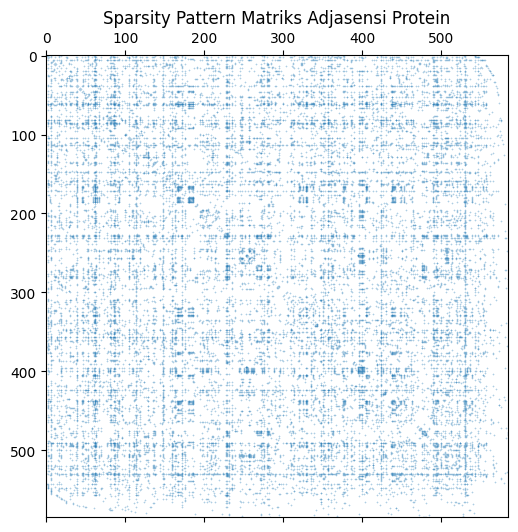

In [ ]:
import matplotlib.pyplot as plt

# Menampilkan informasi ringkas matriks
print(f"Jumlah Simpul (Nodes): {N}")
print(f"Jumlah Tepi (Edges): {A.nnz // 2}") # Dibagi 2 karena matriks simetris

# Visualisasi Sparsity Matriks untuk melihat kerapatan interaksi
plt.figure(figsize=(6, 6))
plt.spy(A, markersize=0.1)
plt.title("Sparsity Pattern Matriks Adjasensi Protein")
plt.show()

In [ ]:
from sklearn.preprocessing import normalize
import nocd
import torch

# Proses normalisasi menggunakan fungsi dari library nocd
# Menghasilkan matriks ternormalisasi (A_hat)
data_norm = normalize(A)

# Transformasi matriks menjadi sparse tensor untuk komputasi PyTorch
adj_norm = nocd.utils.to_sparse_tensor(data_norm)

# Saran Tambahan: Cek dimensi input untuk memastikan kestabilan
print(f"Dimensi Matriks Ternormalisasi: {adj_norm.shape}")

Dimensi Matriks Ternormalisasi: torch.Size([585, 585])
